<a href="https://colab.research.google.com/github/Kayla-afk/Tugas-Kuliah-D4-Sains-Data-Terapan/blob/main/DM_M5_3324600023_Kayla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup dan Import Library

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

Load Dataset

In [2]:
dataset = pd.read_csv('/content/titanic.csv')

Split Dataset (Train dan Test + Label)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
# Pisahkan fitur dan label
X = dataset[['Age', 'Fare']]
y = dataset['Survived']

# Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Handle Missing Values (Train)

In [8]:
# Catat posisi missing
pos_missing_train = X_train[X_train.isnull().any(axis=1)].index

# Hapus missing
X_train_clean = X_train.dropna()

# Sesuaikan label
y_train_clean = y_train.loc[X_train_clean.index]

Handle Missing Values (Test)

In [9]:
# Catat posisi missing
pos_missing_test = X_test[X_test.isnull().any(axis=1)].index

# Hapus missing
X_test_clean = X_test.dropna()

# Sesuaikan label
y_test_clean = y_test.loc[X_test_clean.index]

Normalisasi Train Data (Min-Max 0-1)


In [11]:
min_vals = X_train_clean.min()
max_vals = X_train_clean.max()

X_train_norm = (X_train_clean - min_vals) / (max_vals - min_vals)

Normalisasi Test Data (Menggunakan min-max train)

In [12]:
X_test_norm = (X_test_clean - min_vals) / (max_vals - min_vals)

KNN + Error Ratio

In [15]:
error_ratios = {}

for k in range(1, 16):
  knn = KNeighborsClassifier(n_neighbors=k)

  # Training
  knn.fit(X_train_norm, y_train_clean)

  # Prediksi
  y_pred = knn.predict(X_test_norm)

  # Error Ratio
  error = np.mean(y_pred != y_test_clean)
  error_ratios[k] = error

# Output
for k, err in error_ratios.items():
  print(f"k = {k}, Error Ratio = {err:.4f}")

k = 1, Error Ratio = 0.3944
k = 2, Error Ratio = 0.3592
k = 3, Error Ratio = 0.3521
k = 4, Error Ratio = 0.3310
k = 5, Error Ratio = 0.3592
k = 6, Error Ratio = 0.3239
k = 7, Error Ratio = 0.3028
k = 8, Error Ratio = 0.3451
k = 9, Error Ratio = 0.3099
k = 10, Error Ratio = 0.3380
k = 11, Error Ratio = 0.3239
k = 12, Error Ratio = 0.3239
k = 13, Error Ratio = 0.3169
k = 14, Error Ratio = 0.3239
k = 15, Error Ratio = 0.3239


Visualisasi

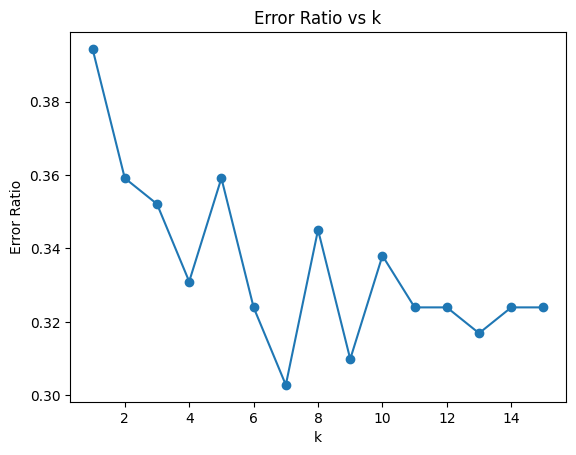

In [17]:
import matplotlib.pyplot as plt

plt.plot(list(error_ratios.keys()), list(error_ratios.values()), marker='o')
plt.xlabel('k')
plt.ylabel('Error Ratio')
plt.title('Error Ratio vs k')
plt.show()